In [206]:
import requests
from IPython.core.display import HTML
# HTML(f"""
# <style>
# @import "https://cdn.jsdelivr.net/npm/bulma@0.9.4/css/bulma.min.css";
# </style>
# """)

### Q11 Exercise Week 13 (Clustering)

#### (a) K-means and Mean shift
- What is clustering and what is its purpose? (benefits and posible pitfalls) (Task 1)
- Explain the K-means clustering algorithm. (Task 3-7)
    - Converges to local minimum of whitin-cluster squared error (variance)
    - depends on the choice of k, sensitive to initial centers, sensitive to outliers
- Explain the Mean shift clustering algorithm. (Task 9-11)
    - Converges to modes of the data density (Formulates clustering as histogram partitioning)
    - does not require specifying number of clusters, can find arbitrarily shaped clusters
    - depends on choice of bandwidth parameter, computationally expensive for large datasets
- Compare K-means and Mean shift clustering algorithms. (Task 17)

#### (b) K-means and Algomerative clustering
- What is clustering and what is its purpose? (benefits and posible pitfalls) (Task 1)
- Explain the K-means clustering algorithm. (Task 3-7)
    - Converges to local minimum of whitin-cluster squared error (variance)
    - depends on the choice of k, sensitive to initial centers, sensitive to outliers
- Explain the Agglomerative clustering algorithm. (Task 12-16)
    - Builds hierarchy of clusters by iteratively merging closest pairs of clusters
    - Does not require specifying number of clusters upfront, can capture complex cluster shapes
    - long runtime, choise of number of clusters or threshold
- Compare K-means and Agglomerative clustering algorithms. (Task 17)

#### (c) Kmeans and ELBOW
- What is clustering and what is its purpose? (benefits and posible pitfalls) (Task 1)
- Explain the K-means clustering algorithm. (Task 3-7)
    - Converges to local minimum of whitin-cluster squared error (variance)
    - depends on the choice of k, sensitive to initial centers, sensitive to outliers
- Explain the ELBOW method for selecting the number of clusters in K-means. (Task 8)
- What is the effect of choosing too few or too many clusters on the clustering results. (Task 8)


# Clustering
This exercise is about clustering (_K-means clustering_, _Mean-shift clustering_, and _Agglomerative_) pose data used for the exercises in week 2
 and week 10
. The task includes applying and experimenting with each method and then comparing their outcomes. The comparison will be conducted by clustering a sequence of human poses using these three methods in similar steps.
The dataset tensor contains 1403 pose sequences. Each sequence is a 100-frames time series capturing human poses. Each pose consists of 25 skeletal joints, where each joint is defined by an x and y coordinate ($25 \cdot 2$). The shape of the dataset tensor is $(1403, 100, 25 \cdot 2)$. For this exercise, you will use a single pose sequence of 100 frames and apply clustering to the sequence.
## Task overview
For each clustering method you will:
- Implement the method.
- Plot the clusters in the sequence.
- Plot the cluster centers.


<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#loading00">Task 1: Introduction</a>
            </li>
            <li>
            <a href="#loading_files">Task 2: Setting up the data</a>
            </li>
            <li>
            <a href="#loading">Task 3: Fitting the algorithm</a>
            </li>
            <li>
            <a href="#loading2">Task 4: K-means clustering visualization</a>
            </li>
            <li>
            <a href="#loading02">Task 5: Cluster characteristics 1</a>
            </li>
            <li>
            <a href="#loading022">Task 6: Cluster centers</a>
            </li>
            <li>
            <a href="#loading023">Task 7: Cluster centers</a>
            </li>
            <li>
            <a href="#loading3">Task 8: Elbow Method</a>
            </li>
            <li>
            <a href="#loading4">Task 9: Fitting the mean-shift algorithm</a>
            </li>
            <li>
            <a href="#loading5">Task 10: Visualizing clusters</a>
            </li>
            <li>
            <a href="#loading9">Task 11: Reflection and the bandwith parameter</a>
            </li>
            <li>
            <a href="#loading10">Task 12: Dendrograms</a>
            </li>
            <li>
            <a href="#loading123">Task 13: Dendogram</a>
            </li>
            <li>
            <a href="#loading11">Task 14: Fitting the agglomerative clustering alg…</a>
            </li>
            <li>
            <a href="#loading12">Task 15: Agglomerative clustreing algorithm mean …</a>
            </li>
            <li>
            <a href="#loading122">Task 16: Agglomerative clustreing algorithm mean …</a>
            </li>
            <li>
            <a href="#loading13">Task 17: Compare and reflect on the methods</a>
            </li>
        </ul>
    </div>
</article>


---
**Task 1 (easy): Introduction💡**
1. Which information can be obtained by clustering a sequence of pose data. Include distance metrics and window size in your discussion.
2. Identify possible pitfalls.


---

In [ ]:
# Write reflections here...

# 1. Which information can be obtained by clustering a sequence of pose data. 
# Include distance metrics and window size in your discussion.

# Clustering means grouping similar data points together based on certain features.
# In the context of pose data, clustering can help identify common patterns or movements.
# For example, if we have pose data from multiple individuals performing the same activity,
# clustering can reveal the typical poses associated with that activity.

# Distance metrics can be used to measure how similar or different two poses are.
# For instanece, Euclidean distance can quantify the straight-line distance between two poses in a multi-dimensional space.
# But different distance metrics may capture different aspects of the pose data.
# For instance, using cosine to measure similarity may be more appropriate when the direction of movement is more important than the magnitude.

# The window size determines the number of consecutive frames or data points considered together.
# If the window size is 1, each pose is treated independently.
# But if the window size is larger, it captures temporal dynamics and transitions between poses.
# A larger window size may help identify sequences of movements, while a smaller window size may focus on individual poses.
# If we want to cluster individual poses, ignoring temporal context, we can use a window size of 1 (as we do in this exercise). 
# Clustering then answers: “Which poses look similar?”
# However, if we want to capture the flow of movements over time, a larger window size would be more appropriate to shift the focus from static posture similarity toward short motion patterns.


# 2. Identify possible pitfalls.
# One potential pitfall is the choice of distance metric.
# Different metrics may yield different clustering results, so it's important to choose one that aligns with the
# specific characteristics of the pose data.
# Another pitfall is the selection of window size.
# A window size that is too small may miss important temporal patterns, while a window size that is too large may smooth out important variations. It depends on the goal of the analysis.
# Additionally, clustering algorithms may be sensitive to noise in the data, which can lead to inaccurate groupings.
# Finally, the different subjects performing the same action may have different body proportions and movement styles,
# which can complicate the clustering process.

The following cells import libraries and provide functions for plotting the poses:


In [208]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
from sklearn.cluster import MeanShift
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import pdist, squareform
import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import dendrogram, linkage
from clustering_utils import *


# Suppress the specific warning
warnings.filterwarnings("ignore")


---
**Task 2 (easy): Setting up the data👩‍💻**
1. Run the cell below to load and reshape the dataset.
2. Choose the 100th pose sequence as the dataset.


---

In [209]:
data = np.load('poses_norm.npy')
N,T,D,C = data.shape
reshaped_data = data.reshape(N,T,D*C)
sequence = reshaped_data[99]
print(sequence.shape)

(100, 50)


## K-means Clustering
In this  exercise you will use k-means clustering on a pose sequence. 

---
**Task 3 (easy): Fitting the algorithm👩‍💻**
1. Run the cell below to create an instance of the `KMeans`
 class with 7 clusters and to find clusters in the sequence.


---

In [210]:
# Specify the number of clusters (k)
k = 8

# Create KMeans 
kmeans = KMeans(n_clusters=k, random_state=42)

# Fit to the data
kmeans.fit(sequence)

KMeans(random_state=42)


---
**Task 4 (easy): K-means clustering visualization👩‍💻**
1. Use the [documentation on the `labels_`
 attribute.](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
 to obtain cluster labels. 
2. Use the `plot_single_pose`
 function from the file `clustering _utils.py`
 to color each pose in the pose sequence according to which cluster it belongs to. 


---

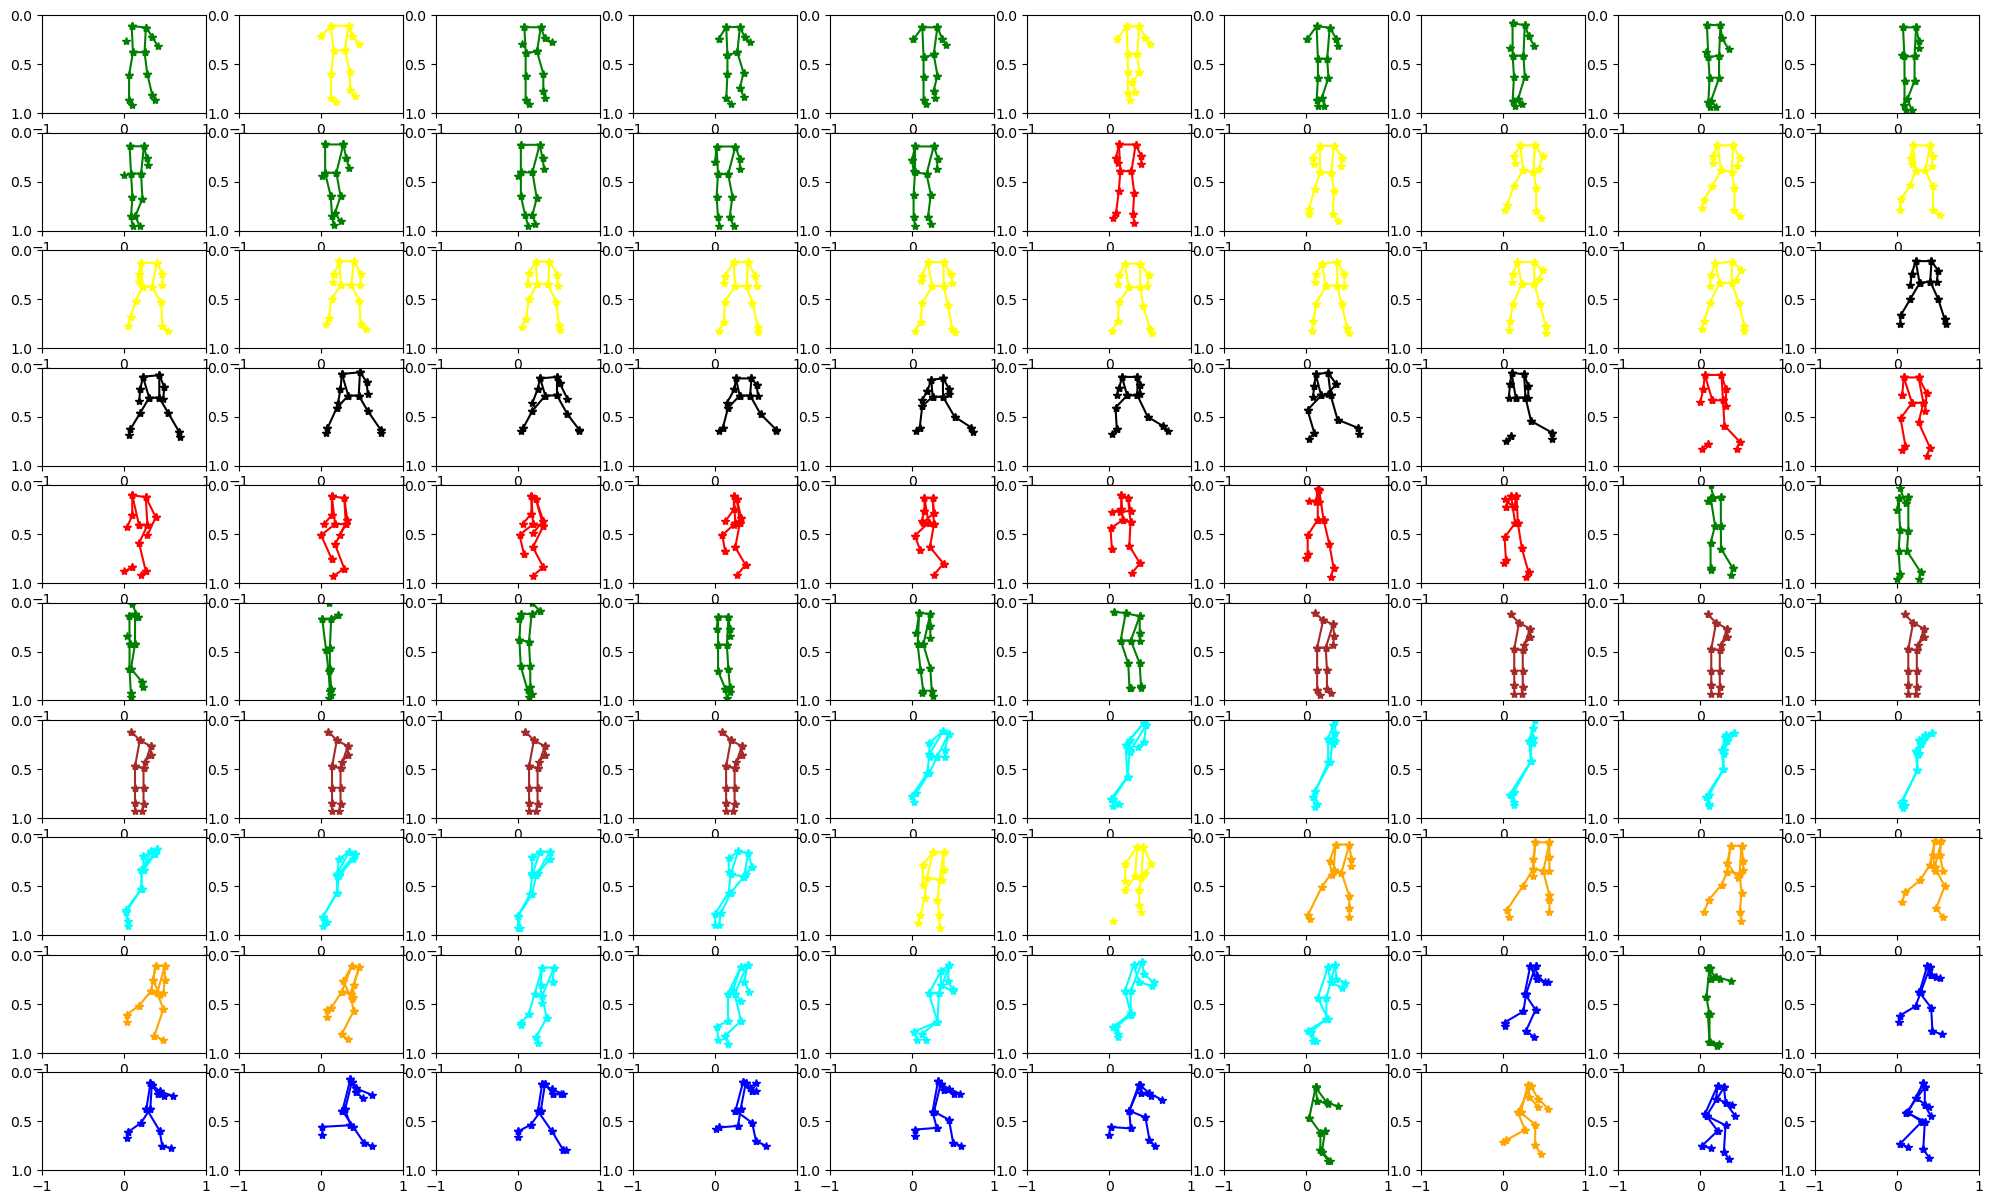

In [211]:
# Write your solution here

# Get cluster labels
cluster_labels = kmeans.labels_ 

# You can now use 'cluster_labels' to see which cluster each frame belongs to
# 'centroids' contains the coordinates of the cluster centers

colors = {0: 'red', 1: 'blue', 2: 'green', 3: "orange", 4: "black", 5: "brown", 6: "yellow", 7: "cyan"}  # Map cluster labels to colors
plt.figure(figsize=(25,15))
for i in range(len(sequence)):
    plt.subplot(10, 10, i + 1)
    plot_single_pose(sequence[i], c=colors[cluster_labels[i]], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)


---
**Task 5 (easy): Cluster characteristics 1💡**
1. What characterizes the _blue_, _green_ and _red_ poses?


---

In [212]:
# Write your reflections here...

#Characteristics of the blue cluster:
# The blue cluster represents poses where the subject are turned to the side (towards right), with arms held out in front 
# and legs apart, a bit bent.

# Characteristics of the green cluster:
# The green cluster represents poses where the subject is facing forward with arms down by their sides (or at least not raised) 
# and legs together or only slightly apart.

# Characteristics of the red cluster:
# The red cluster represents poses where the subject is facing a bit toward the left with arms down by their sides (or at least not raised) 
# and legs apart. I am not completely sure about the difference between the red and brown clusters though but maybe the brown cluster has the subject facing more directly forward.



---
**Task 6 (easy): Cluster centers👩‍💻**
1. Run the cell below to extract and plot the cluster centers.


---

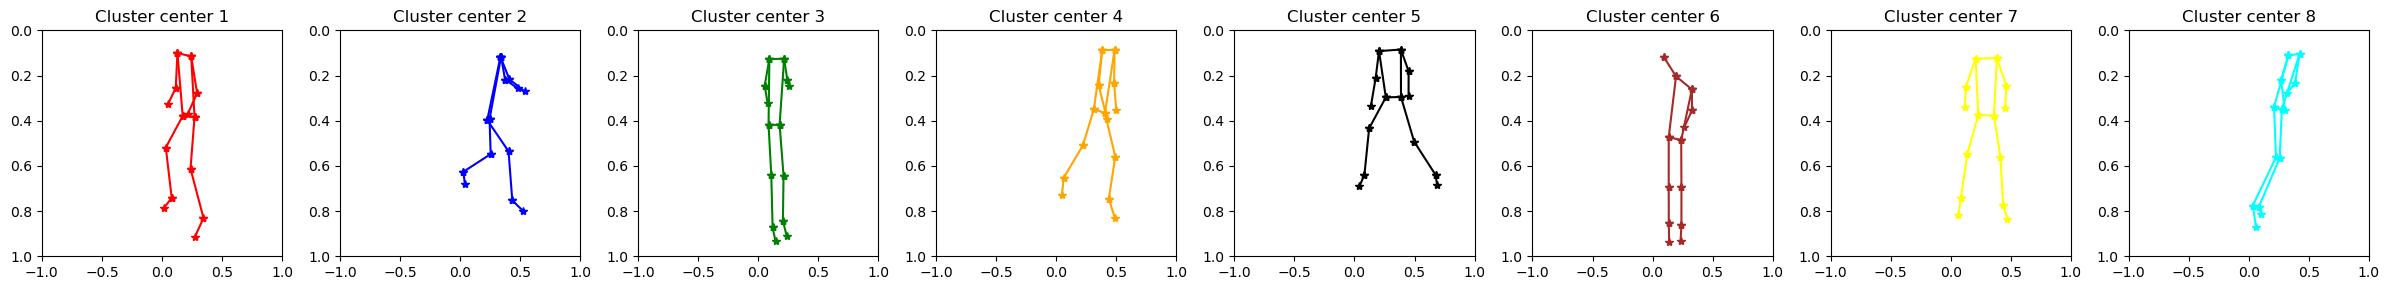

In [213]:
centroids = kmeans.cluster_centers_ # added this line to get centroids
num_centroids = len(centroids)
# Set up subplots
fig, axes = plt.subplots(1, num_centroids, figsize=(num_centroids * 3, 3))

# Assuming you have a function plot_single_pose defined
for i in range(len(centroids)):
    plt.subplot(1, len(centroids), i+1)
    plt.title(f'Cluster center {i+1}')
    plot_single_pose(centroids[i], c=colors[i], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)

plt.tight_layout()
plt.show()


---
**Task 7 (easy): Cluster centers👩‍💻💡📽️**
1. Visually inspect the results and identify the characteristics of the poses in each cluster: 
    - What distinguishes the clusters?
    - What do the cluster centers represent?
    - What do the clusters reveal about poses?
    - How do the cluster centers relate to your observations in [Task 5](#loading02)?


2. Reason about the choice of 7 clusters and the effect on the result.

3. Change the random state and fit the model again. Explain whether you obtain different groupings and why? 



---

In [214]:
# Write your reflections here...

# 1. Visually inspect the results and identify the characteristics of the poses in each cluster: 
#     - What distinguishes the clusters?
# The clusters are distinguished by the orientation of the body (facing forward, left, or right),
# the position of the arms (raised, down by sides, or held out in front),
# and the stance of the legs (together, apart, or bent).
#     - What do the cluster centers represent?
# The cluster centers represent the average pose for each cluster, capturing the most common features of the poses within that cluster.
#     - What do the clusters reveal about poses?
# The clusters reveal that there are distinct categories of poses based on body orientation and limb positions.
# These categories can help in understanding common movement patterns or actions.
#     - How do the cluster centers relate to your observations in [Task 5](#loading02)?
# The cluster centers align with the observations made in Task 5, 
# and are even more clear here since we can see the average pose for each cluster, 
# whereas some individual poses in Task 5 might have been more ambiguous, because they were somewhere in between two clusters.

# 2. Reason about the choice of 7 clusters and the effect on the result.
# If too few clusters are chosen, distinct poses may be grouped together, losing important information.
# Conversely, too many clusters may lead to overfitting, where minor variations in poses are treated as separate clusters.
# The choice of 7 clusters seems to strike a balance, capturing the main variations in poses without overcomplicating the model.

# 3. Change the random state and fit the model again. Explain whether you obtain different groupings and why? 
# Changing the random state can lead to different initializations of the cluster centroids,
# which may result in different final cluster assignments.
# We see this as the categories of poses in each cluster also change when we change the random state.
# The categories which are most distinct (like arms raised vs arms down) are more likely to remain consistent across different random states,
# while more ambiguous categories may shift between clusters (e.g., slight variations in how spread the legs are).
# Working with big data sets this effect is less pronounced though, as the large amount of data helps stabilize the clustering results.
# But with smaller datasets like this one, the effect of random initialization can be more significant.


This task is about using the Elbow Method to choose the number of clusters `k`
.

---
**Task 8 (medium): Elbow Method👩‍💻💡📽️**
The cell below:
- Applies k-means clustering to the sequence using each `k`
 in the interval `k_range`
.
- Extracts the within-cluster sum of squares (WCSS) using [`kmeans.intertia_`
](https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.KMeans.html)
 and store it in a list.
- Plots the within-cluster sum of squares as a function of the number of clusters (elbow curve as displayed below) 

1. Explain the reasons for using WCSS to choose the number of clusters. 

2. What charaterizes the optimal WCSS for choosing the number of clusters?

3. Visually determine the optimal number of clusters.

4. Calculate the rate of change for the elbow curve and plot its absolute value. Use the curve to determine the optimal `k`
.

5. Revisit and run the previous tasks ([Task 3](#loading), [Task 4](#loading2) and [Task 5](#loading02) ) with the optimal number of clusters. 

6. How does the elbow method influence the results in the previous tasks?



---

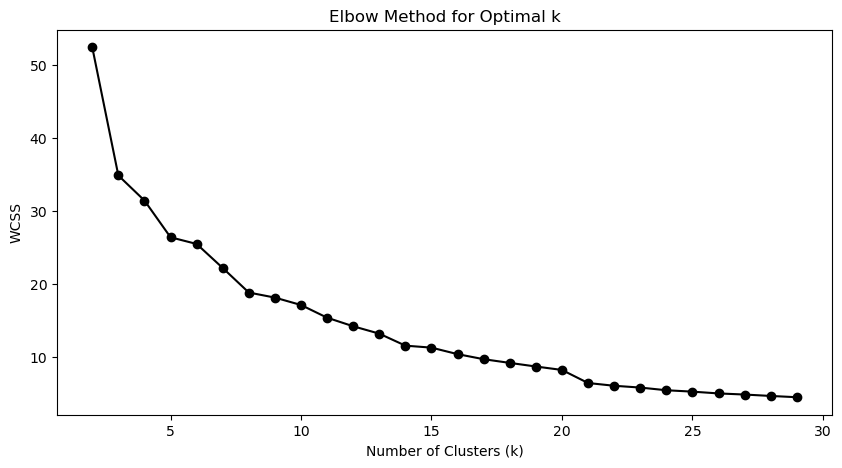

In [215]:
# Find the optimal k using the elbow method
k_range = range(2, 30) # values for the number of clusters `k`
inertia = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(sequence)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()

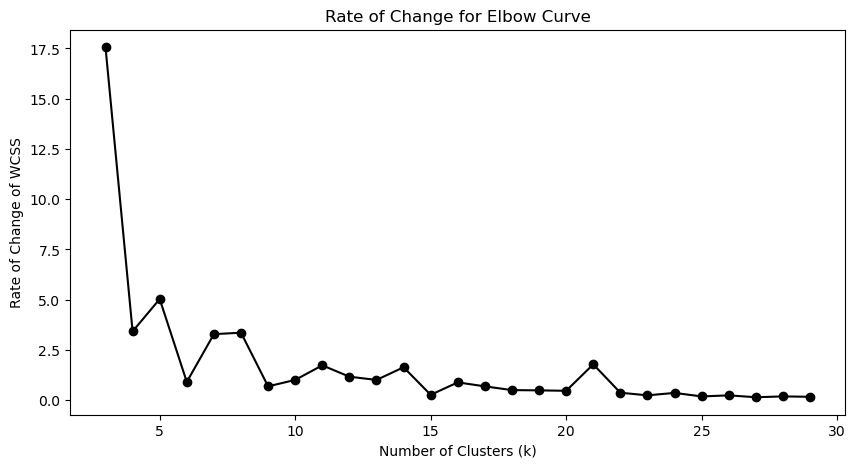

In [216]:
# Write your reflections here...

# Elbow Method👩‍💻💡📽️**
# The cell below:
# - Applies k-means clustering to the sequence using each `k` in the interval `k_range`.
# - Extracts the within-cluster sum of squares (WCSS) using [`kmeans.intertia_`](https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.KMeans.html) and store it in a list.
# - Plots the within-cluster sum of squares as a function of the number of clusters (elbow curve as displayed below) 

# 1. Explain the reasons for using WCSS to choose the number of clusters. 
# WCSS (Within-Cluster Sum of Squares) is the sum of squared distances between each point in a cluster and the centroid of that cluster.
# We want to minimize WCSS because lower values indicate that the points are closer to their centroids,
# meaning the clusters are more compact and well-defined.
# By plotting WCSS against the number of clusters (k), we can observe how adding more clusters affects the compactness of the clusters.
# The goal is to find a balance where adding more clusters does not significantly improve the compactness,
# which is often indicated by an "elbow" in the plot (The point where the rate of decrease sharply changes).

# 2. What charaterizes the optimal WCSS for choosing the number of clusters?
# The optimal WCSS is characterized by a point on the elbow curve where the rate of decrease in WCSS starts to slow down significantly.
# This point indicates that adding more clusters beyond this number does not lead to substantial improvements in cluster compactness.
# It represents a trade-off between having enough clusters to capture the data's structure and avoiding overfitting by using too many clusters.

# 3. Visually determine the optimal number of clusters.
# By visually inspecting the elbow curve, the optimal number of clusters appears to be around 8,
# as this is where the curve starts to flatten out, indicating that adding more clusters beyond this point yields diminishing returns in terms of reducing WCSS.

# 4. Calculate the rate of change for the elbow curve and plot its absolute value. Use the curve to determine the optimal `k`
diff_inertia = np.diff(inertia)
abs_diff_inertia = np.abs(diff_inertia)
plt.figure(figsize=(10, 5))
plt.plot(k_range[1:], abs_diff_inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Rate of Change of WCSS')
plt.title('Rate of Change for Elbow Curve')
plt.show()

# Based on the rate of change plot, the optimal `k` appears to be around 8 as expected.

# 5. Revisit and run the previous tasks ([Task 3](#loading), [Task 4](#loading2) and [Task 5](#loading02) ) with the optimal number of clusters. 

# 6. How does the elbow method influence the results in the previous tasks?
# Since the cluster before was 7 and the optimal is 8, the results are quite similar.
# However, with 8 clusters, we might capture an additional nuance in the pose data that was previously grouped together.
# This could lead to more accurate and meaningful clusters, providing better insights into the pose variations.


## Mean-shift Clustering
This exercise is about applying mean-shift clustering to the sequence of poses. 

---
**Task 9 (easy): Fitting the mean-shift algorithm👩‍💻**
1. Run the cell below to:    
   - create an instance of the `MeanShift()`
 class with a bandwith of 0.629 
   - cluster the pose sequence.




---

In [236]:
# Perform Mean Shift clustering
mean_shift = MeanShift(bandwidth=0.629)
mean_shift.fit(sequence)

MeanShift(bandwidth=0.629)


---
**Task 10 (easy): Visualizing clusters👩‍💻**
1. Extract the cluster labels for each pose in the sequence. Use the `labels_`
 attribute as described in the [documentation on mean-shift clustering.](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MeanShift.html)

2. Visualize the pose sequence, assigning a distinct color to each pose based on its cluster.
3. Extract and plot the cluster centers using the `cluster_centers_`
 attribute.


---

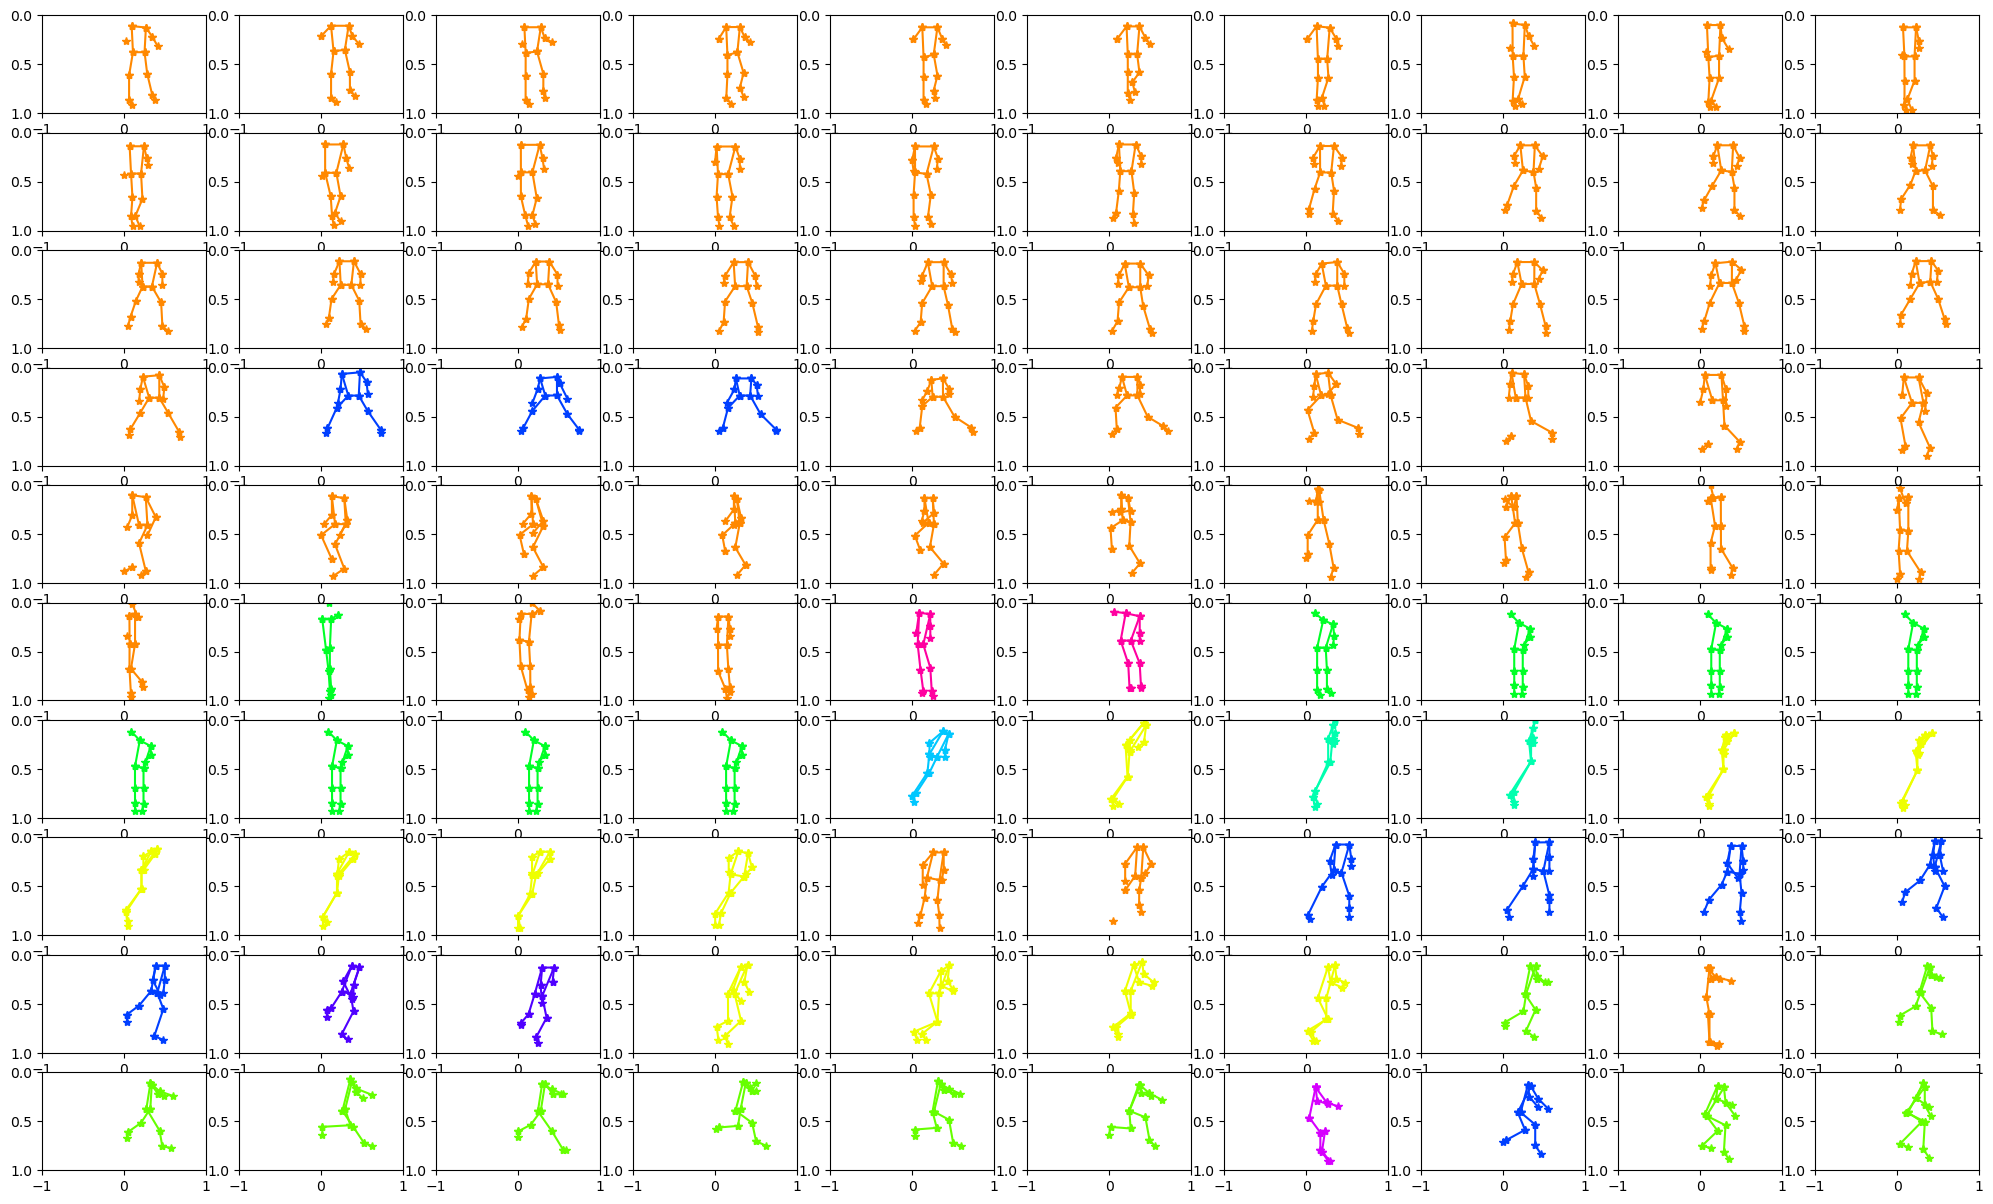

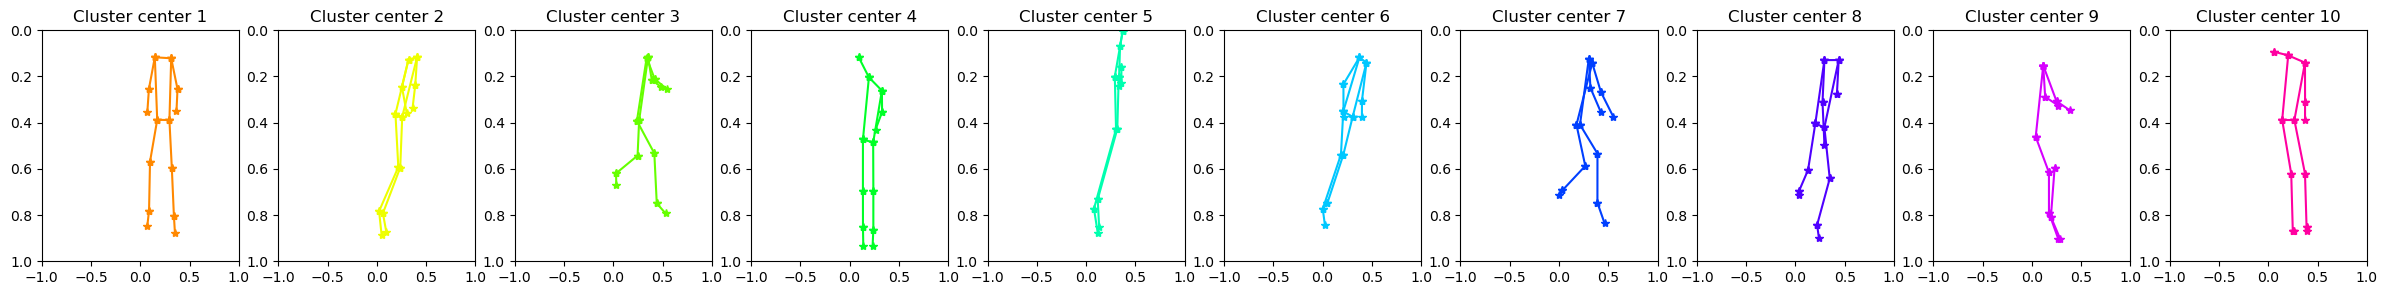

In [237]:
# Write your solution here

# 1 Get cluster labels
cluster_labels = mean_shift.labels_

# 2 Visualize the poses with distinct colors for each cluster
colors = sns.color_palette("hsv", np.unique(cluster_labels).shape[0])  # Generate distinct colors
plt.figure(figsize=(25,15))
for i in range(len(sequence)):
    plt.subplot(10, 10, i + 1)
    plot_single_pose(sequence[i], c=colors[cluster_labels[i]], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)

# 3 Extract and visualize cluster centers
centroids = mean_shift.cluster_centers_
num_centroids = len(centroids)

fig, axes = plt.subplots(1, num_centroids, figsize=(num_centroids * 3, 3))
for i in range(len(centroids)):
    plt.subplot(1, len(centroids), i+1)
    plt.title(f'Cluster center {i+1}')
    plot_single_pose(centroids[i], c=colors[i], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)



---
**Task 11 (easy): Reflection and the bandwith parameter👩‍💻💡**
1. Visually examine the plots. What are the characteristics of the poses belonging to each cluster?
2. What is the purpose and what effect of decreasing and increasing the bandwidth parameter to 0.429 and 0.829 have and why?


**Info**
You might encounter longer run times for lower bandwith values.


---

In [ ]:
# Write your reflections here...

# 1. Visually examine the plots. What are the characteristics of the poses belonging to each cluster?
# The characteristics of the poses in each cluster vary based on body orientation, arm positions, and leg stancees (like before).
# Cluster 1: facing forward, arms down, legs slightly apart.
# Cluster 2: facing right, arms held down along the body, legs together and slightly bent.
# Cluster 3: facing left, arms in front, legs apart.
# Cluster 4: facing forward, an arm raised, legs together.
# Cluster 5: facing right, arms down, legs together. (looks very similar to cluster 2)
# Cluster 6: facing right (slightly turning the upper body), arms down, legs together.
# Cluster 7: facing right, arms a bit raised, legs apart and bent.
# Cluster 8: facing forward, arms down, legs apart, one behind the other (a bit shorter than the other).
# Cluster 9: facing right, arms a bit raised, legs together.
# Cluster 10: facing forward, one arm a bit raised, legs together, or slightly apart.

# 2. What is the purpose and what effect of decreasing and increasing the bandwidth parameter to 0.429 and 0.829 have and why?
# The bandwidth determines, how close points need to be to each other to be considered part of the same cluster.
# Decreasing the bandwidth to 0.429 results in more clusters (29 clusters), as points need to be closer together to be grouped.
# This can capture finer details in the data but may also lead to over-segmentation.
# Increasing the bandwidth to 0.829 results in fewer clusters (6 clusters), as points can be farther apart and still be grouped together.
# This can help identify broader patterns but may overlook important variations in the data.
# The choice of bandwidth should balance capturing meaningful patterns without overfitting or underfitting the data.

With bandwith 0.429:
![bandwith 0.429](bandwith0429.png)

With bandwith 0.829:
![bandwith 0.829](bandwith0829.png)

## Agglomerative Clustering
This exercise is about applying hierarchical clustering to the poses dataset.

---
**Task 12 (easy): Dendrograms👩‍💻**
1. Run the cell below to generate a dendrogram. 


---

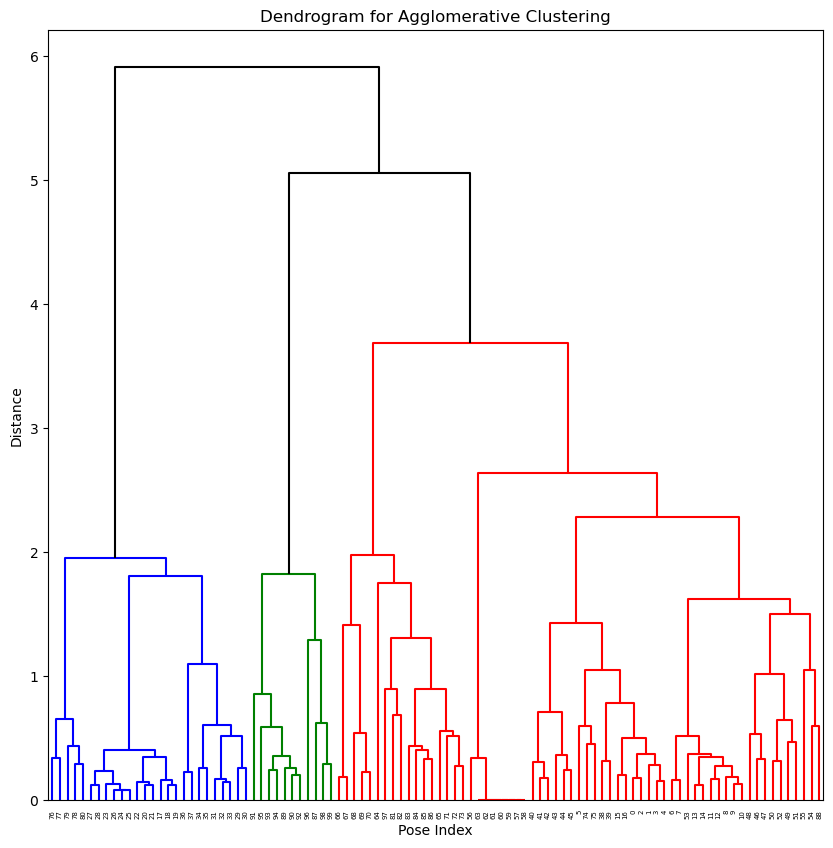

In [325]:
colors = {0: 'black', 1: 'blue', 2: 'green', 3: 'red'}
sns.set_palette([colors[i] for i in range(len(colors))])
shc.set_link_color_palette(None)
plt.figure(figsize=(10,10))
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Pose Index')
plt.ylabel('Distance')
linkage_matrix = shc.linkage(sequence, method ='ward', metric="euclidean") # to choose l1, i have to change metric to "cityblock"
Dendrogram = shc.dendrogram(linkage_matrix)


---
**Task 13 (easy): Dendogram💡📽️**
1. How can the number of clusters be determined from the dendrogram?
2. What does the location of a merge node in the dendrogram represent? If two points merge at a very low height, what does it tell about them?
3. Explain what a large differences in node location in the dendogram imply.
4. How many clusters would result from setting the distance threshold to: 0.5, 1.5, 3.0, 4?
5. What types of relationships can agglomerative clustering reveal that non-hierarchical methods might miss?


---

In [242]:
# Write your reflection here...

# 1. How can the number of clusters be determined from the dendrogram?
# The number of clusters can be determined by cutting the dendrogram at a specific height (distance threshold).
# Each vertical line that is intersected by the cut represents a cluster.
# By choosing a height to cut the dendrogram, we can see how many clusters are formed at that level of similarity.

# 2. What does the location of a merge node in the dendrogram represent? If two points merge at a very low height, what does it tell about them?
# The location of a merge node in the dendrogram represents the distance (or dissimilarity) at which two clusters are merged.
# If two points merge at a very low height, it indicates that they are very similar to each other,
# meaning they have a small distance between them in the feature space used for clustering.

# 3. Explain what a large differences in node location in the dendogram imply.
# Large differences in node location in the dendrogram imply that there are significant differences in similarity between clusters.
# If two clusters merge at a high height, it indicates that they are quite dissimilar,
# meaning they have a large distance between them in the feature space.

# 4. How many clusters would result from setting the distance threshold to: 0.5, 1.5, 3.0, 4?
# We can either count the clusters visually from the dendrogram or use code to find the exact number. 
from scipy.cluster.hierarchy import fcluster
def num_clusters_at_distance(threshold):
    clusters = fcluster(linkage_matrix, threshold, criterion='distance')
    return len(np.unique(clusters))
# - At distance 0.5: 
print("Clusters at distance 0.5:", num_clusters_at_distance(0.5))  # 40 clusters at distance 0.5. (By counting i got around 37, so the code is more precise)
# - At distance 1.5: 
print("Clusters at distance 1.5:", num_clusters_at_distance(1.5))  # 12 clusters at distance 1.5.
# - At distance 3.0:
print("Clusters at distance 3.0:", num_clusters_at_distance(3.0))  # 4 clusters at distance 3.0.
# - At distance 4.0:
print("Clusters at distance 4.0:", num_clusters_at_distance(4.0))  # 3 clusters at distance 4.0.

# 5. What types of relationships can agglomerative clustering reveal that non-hierarchical methods might miss?
# (What is agglomerative clustering? It is a hierarchical clustering method that builds nested clusters by merging or splitting them based on their similarity.
# Thus, it creates a tree-like structure (dendrogram) that shows the relationships between clusters at different levels of granularity.)
# Agglomerative clustering can reveal hierarchical relationships between data points,
# showing how clusters are formed at different levels of similarity.
# This allows us to see the nested structure of clusters, which non-hierarchical methods like k-means or mean-shift do not provide.
# Non-hierarchical methods assign points to clusters without showing how those clusters relate to each other at different levels of granularity.
# By looking at the dendrogram, we can understand how closely related different clusters are,
# and are able to see sub-clusters within larger clusters - how they are nested, and determine if they should be grouped together or treated separately.
# If for example there is a big jump in distance between two merge nodes, it indicates that the clusters being merged are quite dissimilar,
# suggesting that they may represent distinct groups in the data that should not be combined.

Clusters at distance 0.5: 40
Clusters at distance 1.5: 12
Clusters at distance 3.0: 4
Clusters at distance 4.0: 3



---
**Task 14 (easy): Fitting the agglomerative clustering algorithm👩‍💻**
1. Run the cell below creates an instance of the `AgglomerativeClustering()`
 class. The [documentation on agglomerative clustering is given here.](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

2. Select the distance threshold that results in 3 clusters, then apply agglomerative clustering on the sequence. 
3. Extract the cluster labels for each pose in the sequence.
4. Visualize the pose sequence by assigning a distinct color to each pose based on its cluster.


---

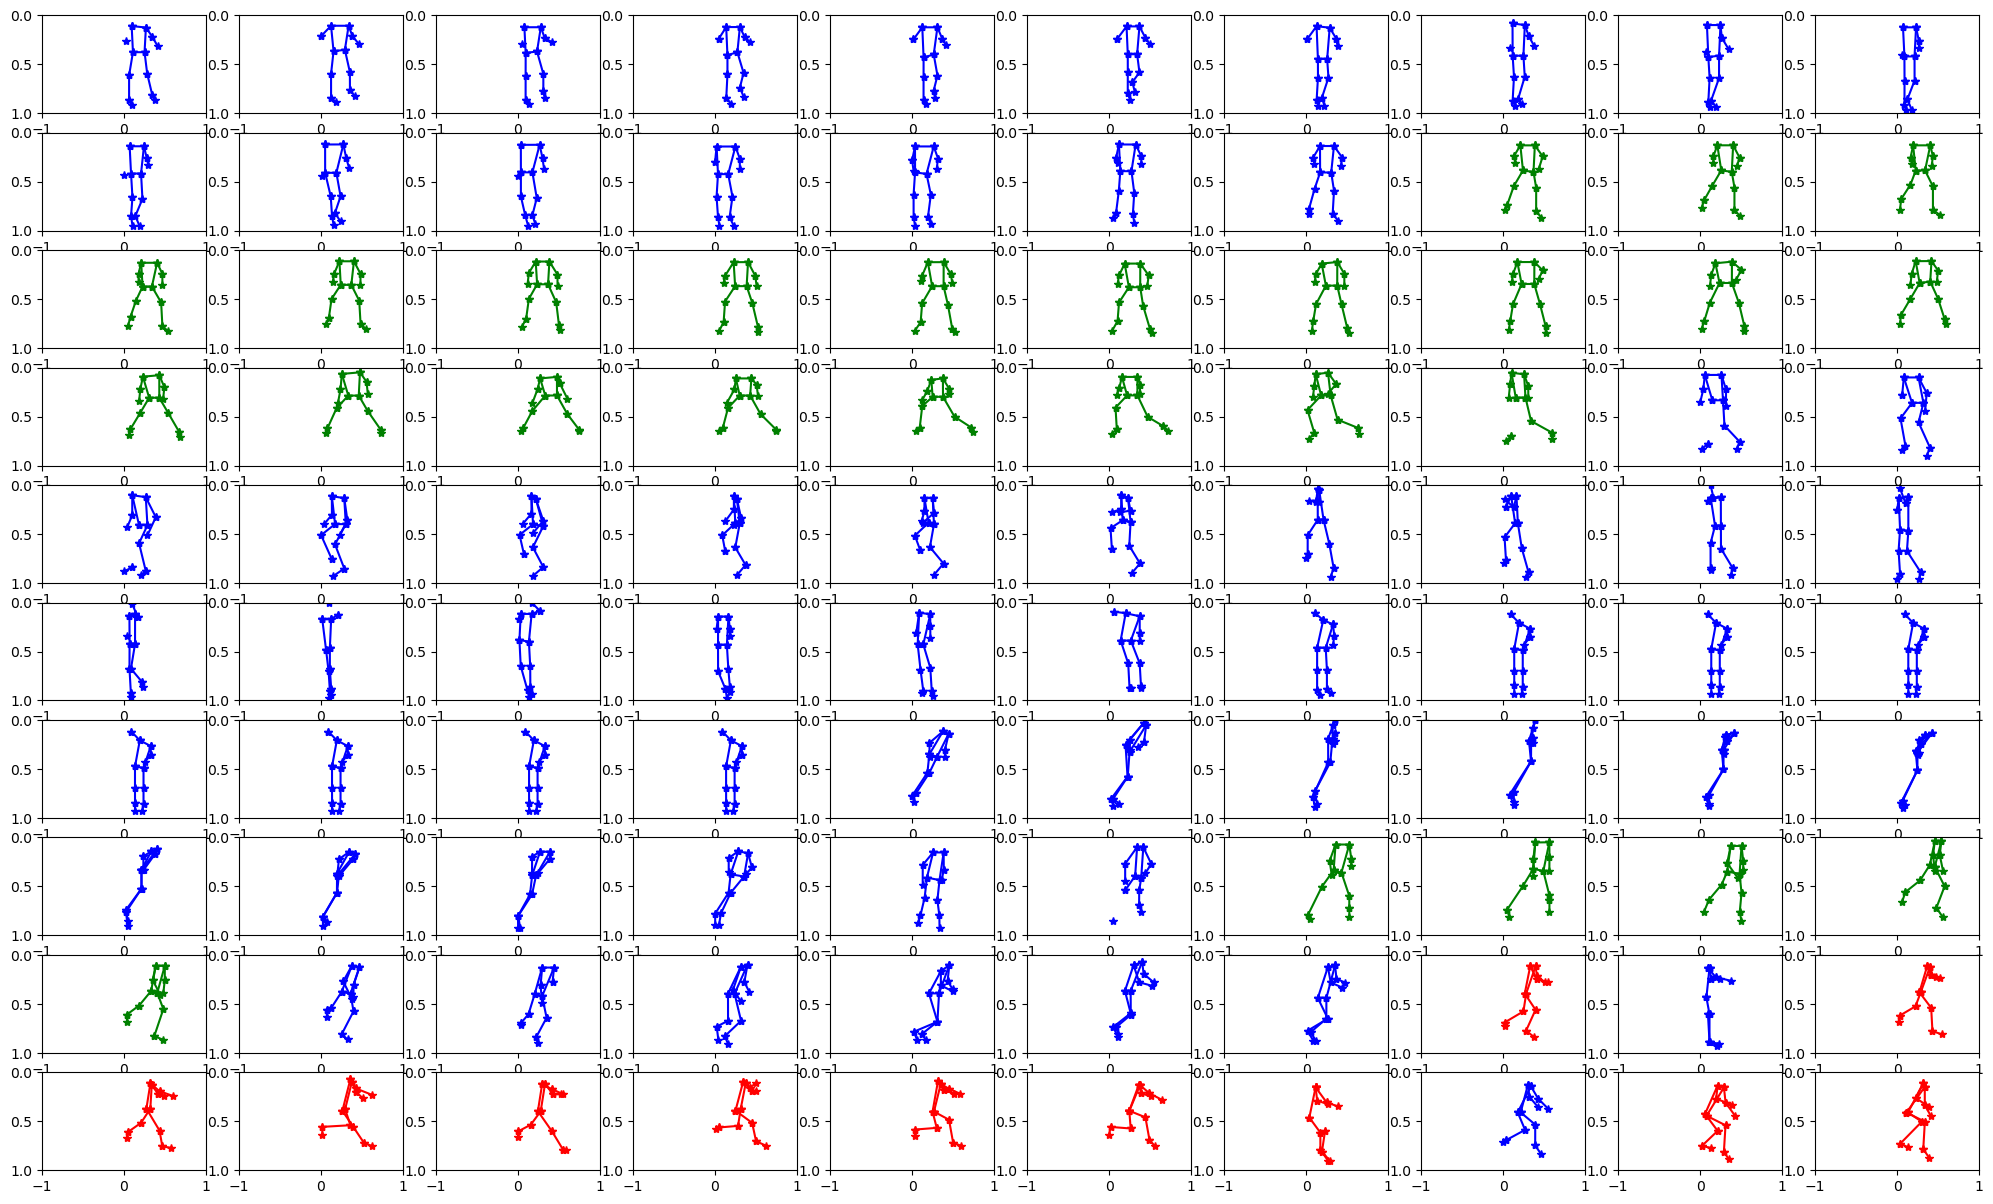

In [290]:
agg_clustering = AgglomerativeClustering(distance_threshold=4, n_clusters=None, metric='euclidean', linkage='ward') # Threshold 4.0 gives 3 clusters

# Write your solution here (agglomerative clustering and cluster centers)
agg_clustering.fit(sequence)
cluster_labels = agg_clustering.labels_ 

#Visualize the poses with distinct colors for each cluster
colors = {0: 'blue', 1: 'green', 2: 'red'}
plt.figure(figsize=(25,15))
for i in range(len(sequence)):
    plt.subplot(10, 10, i + 1)
    plot_single_pose(sequence[i], c=colors[cluster_labels[i]], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)


---
**Task 15 (easy): Agglomerative clustreing algorithm mean pose👩‍💻**
1. The `AgglomerativeClustering()`
 class does not have a method for directly extracting cluster centers. Calculate the mean pose within each cluster for $k = 3$  and plot it.
2. Change the distance metric (try `l1`
 and `cosine`
) and repeat the previous two tasks ([Task 14](#loading11) and [Task 15](#loading12).1). 


---

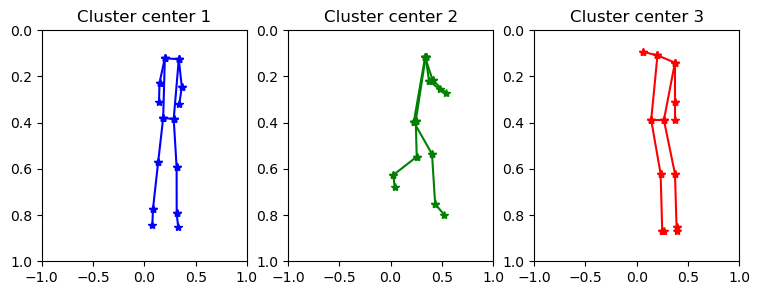

In [303]:
# Write your solution here
# 1. The `AgglomerativeClustering()`  class does not have a method for directly extracting cluster centers. 
# Calculate the mean pose within each cluster for $k = 3$  and plot it.


# Calculate mean pose for each cluster
k=3
centroids = []
for cluster_id in range(k):
    cluster_points = sequence[cluster_labels == cluster_id]
    mean_pose = np.mean(cluster_points, axis=0)
    centroids.append(mean_pose)

# Visualize cluster centers
num_centroids = len(centroids)
fig, axes = plt.subplots(1, num_centroids, figsize=(num_centroids * 3, 3))
for i in range(len(centroids)):
    plt.subplot(1, len(centroids), i+1)
    plt.title(f'Cluster center {i+1}')
    plot_single_pose(centroids[i], c=colors[i], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)


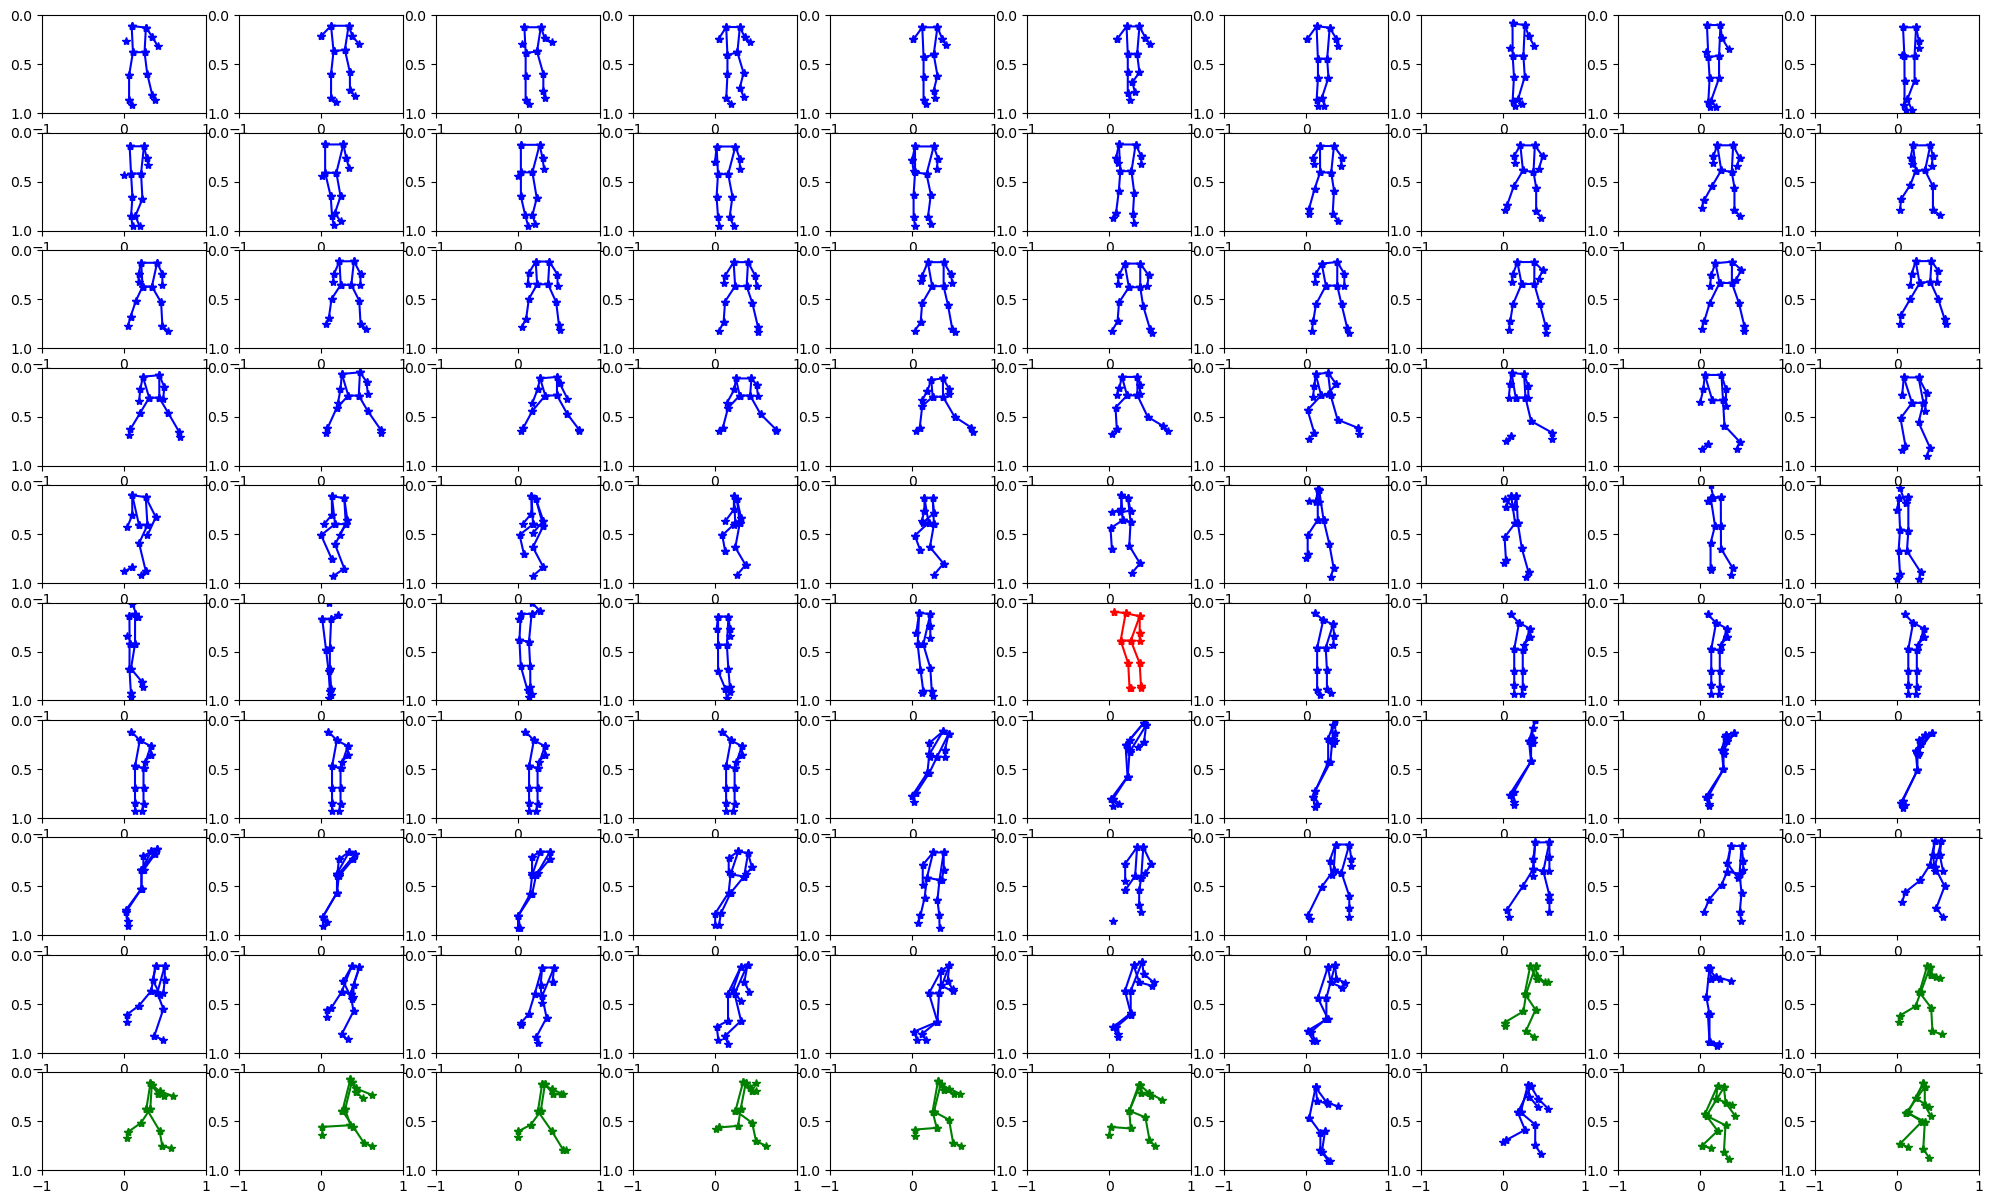

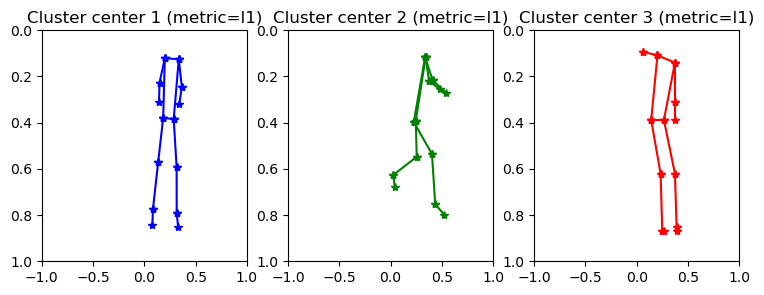

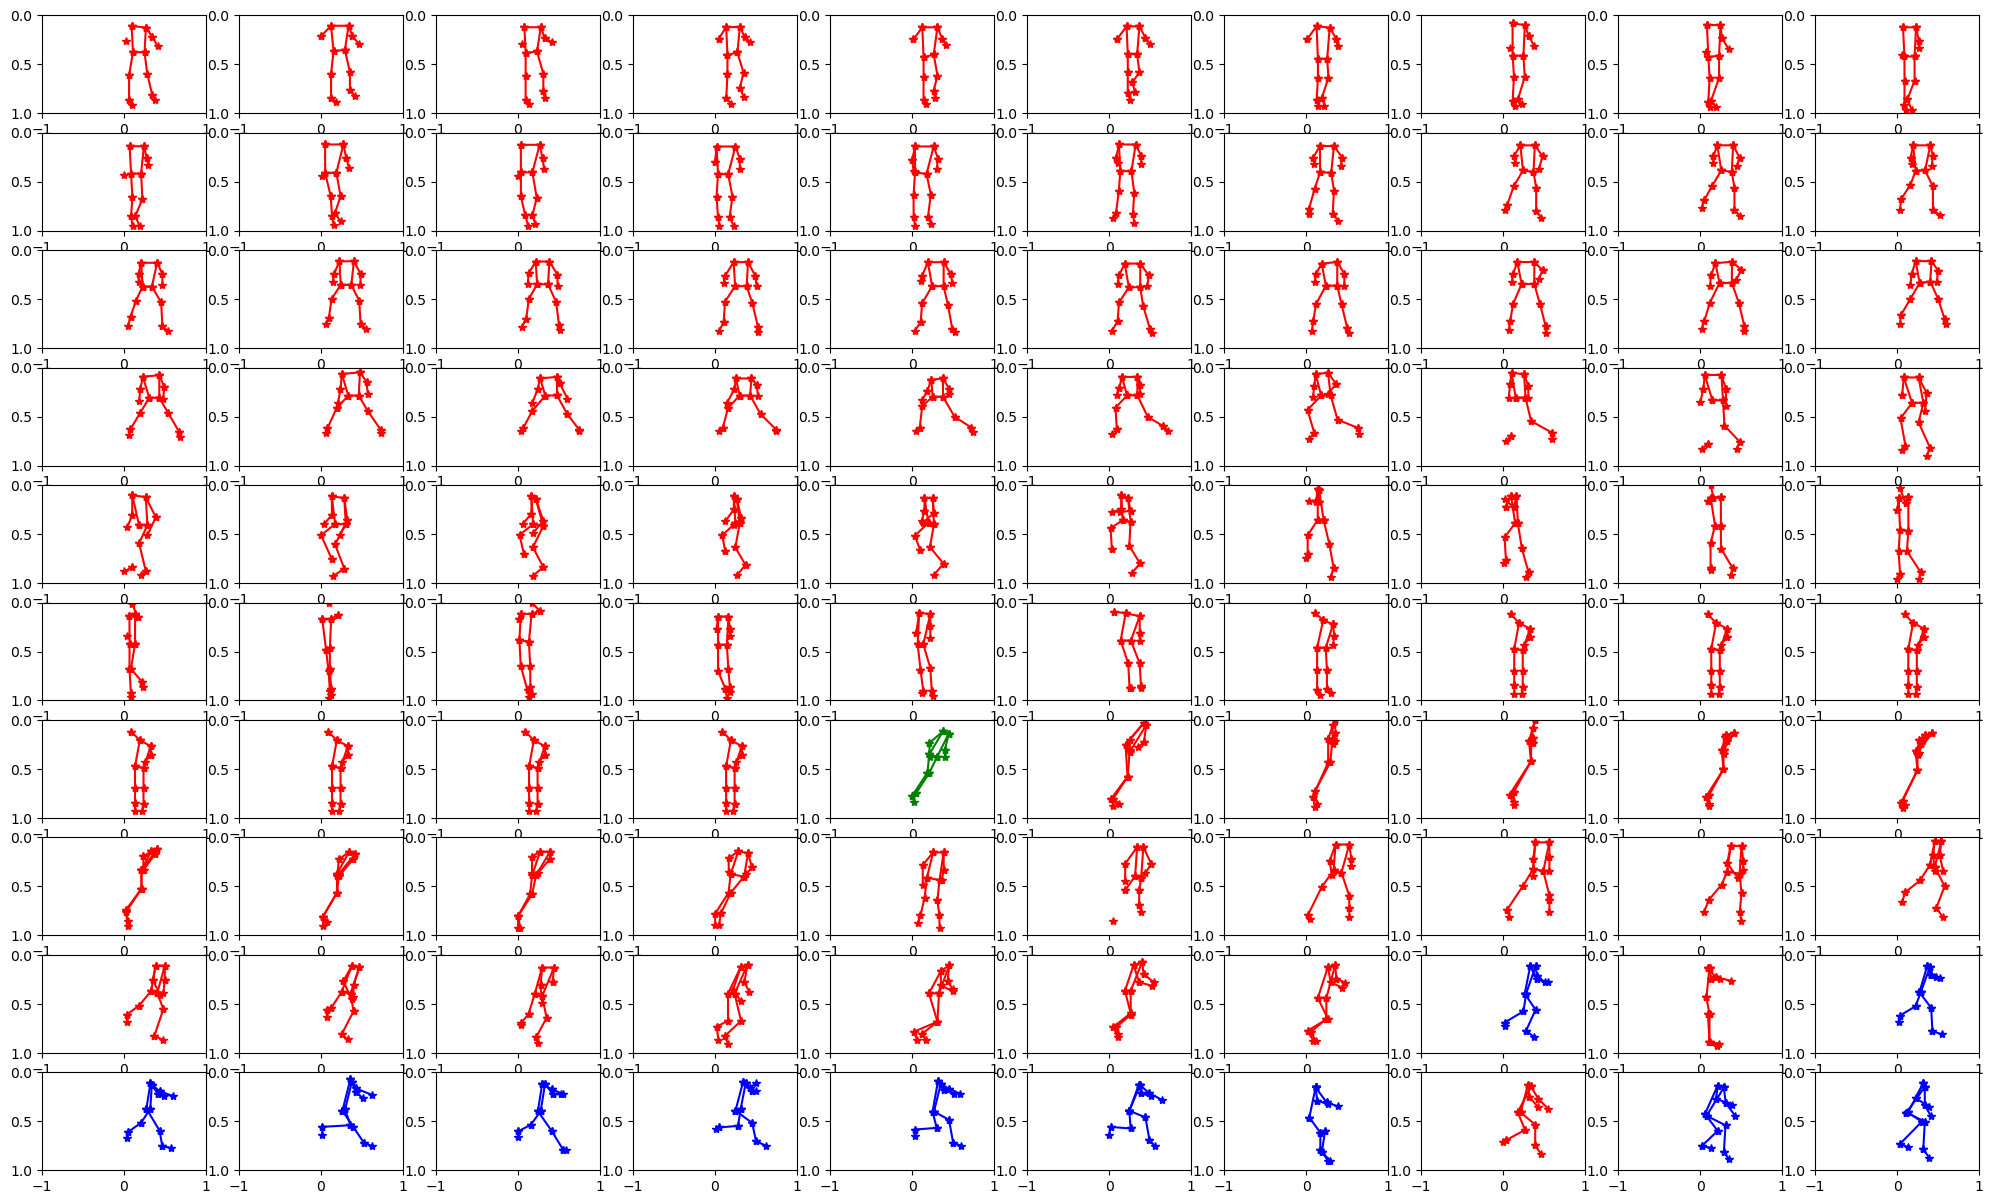

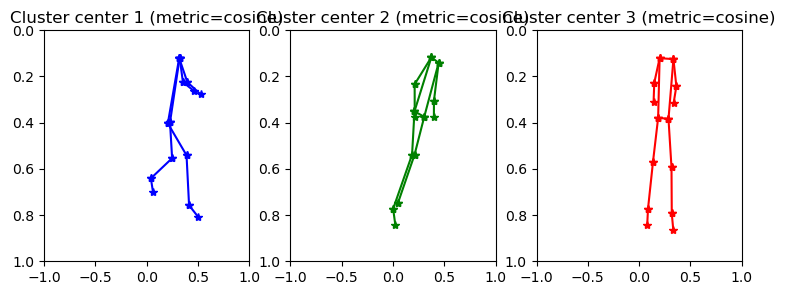

In [310]:

# 2. Change the distance metric (try `l1`  and `cosine` ) and repeat the previous two tasks ([Task 14](#loading11) and [Task 15](#loading12).1). 

from sklearn.discriminant_analysis import unique_labels


def agglomerative_clustering_and_visualization(sequence, k, distance_metric):
    if distance_metric == 'euclidean':
        agg_clustering = AgglomerativeClustering(distance_threshold=4, n_clusters=None, metric='euclidean', linkage='ward')
    else:
        agg_clustering = AgglomerativeClustering(n_clusters=k, metric=distance_metric, linkage='average') #  If linkage is “ward”, only “euclidean” is accepted
    
    # Fit the model
    agg_clustering.fit(sequence)
    cluster_labels = agg_clustering.labels_ 

    # Visualize the poses with distinct colors for each cluster
    unique_labels = np.unique(cluster_labels)
    colors = {0: 'blue', 1: 'green', 2: 'red'}
    plt.figure(figsize=(25,15))
    for i in range(len(sequence)):
        plt.subplot(10, 10, i + 1)
        plot_single_pose(sequence[i], c=colors[cluster_labels[i]], head=False)
        plt.ylim(1, 0)
        plt.xlim(-1, 1)

    # Calculate mean pose for each cluster
    centroids = []
    for cluster_id in unique_labels:
        cluster_points = sequence[cluster_labels == cluster_id]
        mean_pose = np.mean(cluster_points, axis=0)
        centroids.append(mean_pose)

    # Visualize cluster centers
    num_centroids = len(centroids)
    fig, axes = plt.subplots(1, num_centroids, figsize=(num_centroids * 3, 3))
    for i in range(len(centroids)):
        plt.subplot(1, len(centroids), i+1)
        plt.title(f'Cluster center {i+1} (metric={distance_metric})')
        plot_single_pose(centroids[i], c=colors[i], head=False)
        plt.ylim(1, 0)
        plt.xlim(-1, 1)


# Run the function for different distance metrics
agglomerative_clustering_and_visualization(sequence, k=3, distance_metric='l1')
agglomerative_clustering_and_visualization(sequence, k=3, distance_metric='cosine')


---
**Task 16 (easy): Agglomerative clustreing algorithm mean pose💡📽️**
1. What differences do you observe?
2. Explain why these differences occur? 
3. Does a different distance metric result in more meaningful clusters, why/why not?


---

In [ ]:
# Write your reflections here...
# 1. What differences do you observe?
# A small note before answering: Since the linkage method was changed to 'average' for the non-euclidean metrics,
# the differences observed are not solely due to the distance metric but also influenced by the change in linkage method.
# I used 'average' linkage because 'ward' linkage only accepts 'euclidean' metric.

# When using the 'l1' distance metric, the cluster centers appear identical to those obtained with 'euclidean' metric.
# It seems that 'l1' metric captures similar pose characteristics as 'euclidean' in this case.
# But when using the 'cosine' distance metric, the cluster centers differ significantly from those obtained with 'euclidean' and 'l1'.
# The poses in the clusters formed using 'cosine' metric show different orientations and limb positions,
# indicating that 'cosine' metric captures different aspects of pose similarity compared to the other two metrics.
# Is this to be expected? 
# Yes, because 'cosine' distance measures the angle between vectors (poses) rather than their absolute differences,
# leading to different clustering results. 
# l1 and euclidean both measure absolute differences, albeit in different ways, leading to more similar clustering outcomes.
# Euclidean measures the straight-line distance (L2 norm), while l1 measures the sum of absolute differences (Manhattan distance, following a grid path).

# 2. Explain why these differences occur? 
# The differences occur because each distance metric captures different aspects of similarity between poses.
# 'Euclidean' distance considers the overall magnitude of differences in joint positions,
# making it sensitive to large deviations in any joint.
# 'L1' distance sums the absolute differences, which can be more robust to outliers
# but still captures overall positional differences ( and in this case resulted in similar clusters as euclidean).
# 'Cosine' distance, on the other hand, focuses on the orientation of the poses 
# by measuring the angle between pose vectors, making it less sensitive to magnitude differences.
# Cosine could be particularly useful if two subjects have very different body proportions but perform the same action,
# as it would group poses based on their relative joint positions rather than absolute positions.

# 3. Does a different distance metric result in more meaningful clusters, why/why not?
# The meaningfulness of clusters depends on the specific application and the characteristics of the pose data.
# If the goal is to capture overall pose similarity considering absolute joint positions,
# 'euclidean' or 'l1' metrics may be more appropriate, as they provide clusters that reflect common pose configurations.
# However, if the focus is on capturing relative joint positions and orientations,
# especially when dealing with subjects of varying body proportions, 'cosine' distance may yield more meaningful clusters.
# In this case, they all seem to provide meaningful clusters, and the choice of metric should be guided by the specific analysis goals and data characteristics.


## Comparison

---
**Task 17 (medium): Compare and reflect on the methods👩‍💻💡📽️**
1. Compare the clustered poses obtained with the different clustering methods (K-means, Mean-shift and Agglomerative clustering). What are the similarities and differences between the pose clusters across methods?
2. Why can clusters look similar across methods? 
3. What are the main reasons behind differences in the clusters?
4. The algorithms use different methods for determining the number of clusters. How do these differences impact the results for the pose data?


---

In [ ]:
# Write your relfection here...

# 1. Compare the clustered poses obtained with the different clustering methods (K-means, Mean-shift and Agglomerative clustering). 
# What are the similarities and differences between the pose clusters across methods?

# Similarities of poses across methods:
# - Poses that are very different in feature space tend to be separated into different clusters across methods, so it is rather the border cases that differ than the most distinct poses.
# - Core pose differences (like arms raised vs arms down) are generally captured across all methods, grouing these highly distinct poses together.
# - Some clusters may appear similar in terms of pose characteristics, such as body orientation and limb positions, across different methods. 

# Differences of poses across methods:
# - The number of clusters vary significantly between methods, leading to different granularity in pose groupings.
# - Some poses may be grouped differently depending on the method, especially those that are borderline cases between clusters: In K-means they are forced into the nearest cluster, while in Mean-shift they may form their own small clusters or be left unclustered.
# - Very distinct poses (outliers) gets their own clusters in Mean-shift and Agglomerative clustering, while K-means forces them into existing clusters, distorting the cluster characteristics.


# 2. Why can clusters look similar across methods? 
# Clusters can look similar across methods because they are all trying to capture the underlying structure of the data.
# And since they all rely on distance metrics to some extent, they may identify similar groupings of poses that are close together in the feature space.


# 3. What are the main reasons behind differences in the clusters?
# The main reasons behind differences in the clusters include:
# - Different clustering algorithms have different assumptions and mechanisms for grouping data points.
# - K-means focuses on minimizing distance to centroids, leading to spherical clusters.
#   It assumes that clusters are of similar size and shape (spherical), which may not always be the case in real-world data.
#   It highly depends on the initial placement of centroids, which can lead to different results across runs.
#   It forces every pose into one of the k clusters, and will thereby be highly influenced by outliers or poses that don't fit well into any cluster.
# - Mean-shift focuses on density estimation, leading to clusters based on data point density.
#   It assumes that clusters are areas of high density separated by areas of low density.
#   It can capture clusters of arbitrary shapes and sizes, as it does not assume any specific cluster shape or number.
#   It is sensitive to the choice of bandwidth parameter, which determines how close points need to be to be considered part of the same cluster.
#   It may leave outliers or less dense areas unclustered (or in their own small clusters), as it focuses on high-density regions.
# - Agglomerative clustering builds a hierarchy of clusters based on pairwise distances, leading to nested clusters.
#   It assumes a hierarchical structure in the data, meaning that clusters can be nested within larger clusters.
#   It is sensitive to the choice of distance metric and linkage method, which can significantly impact the resulting clusters.
#   The choice of linkage metric and distance metric determines how sensitive the clustering is to outliers and the shape of clusters.
#   E.g. using 'ward' linkage with 'euclidean' distance tends to create compact, spherical clusters,
#   while using 'average' linkage with 'cosine' distance may lead to more irregularly shaped clusters.
#   Regarding outliers, agglomerative clustering will still assign them to the nearest cluster,
#   but since the clustering is based on pairwise distances, outliers will be in their own small clusters until they are merged with larger clusters at higher distances in the dendrogram.
#   This means that outliers may have less influence on the overall clustering structure compared to K-means, since they can be isolated at lower levels of the hierarchy.

# 4. The algorithms use different methods for determining the number of clusters. How do these differences impact the results for the pose data?
# - K-means requires a predefined number of clusters (k), which can lead to suboptimal clustering if k is not chosen appropriately.
# - Mean-shift automatically determines the number of clusters based on the data distribution and bandwidth parameter,
#   which can lead to more adaptive clustering but may also result in too many or too few clusters if the bandwidth is not set correctly.
# - Agglomerative clustering allows for flexibility in choosing the number of clusters by cutting the dendrogram at different heights,
#   which can lead to different clusterings based on the chosen distance threshold. 
#   You have the freedom to either specify the number of clusters directly or let the algorithm decide based on distance.
#   A dendogram can help visualize the hierarchical relationships between clusters, and make more informed decisions about the number of clusters/distance threshold.
